In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds
from src.visualizations.umap_visualizer import UMAPLatent

In [53]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [54]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, dropout=self.dropout)
        # self.linear = nn.Linear(self.hidden_size, self.hidden_size)


    def forward(self, x):
        """
        x: (seq_len, batch_size, input_size=1)
        """
        output, (hidden, cell) = self.lstm(x)
        # output: (seq_len, batch_size, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers. batch_size, hidden_size)
        embeddings = hidden[-1, :, :]
        # embeddings = output[-1, :, :]
        return hidden, cell, embeddings
    
class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.output_size, self.hidden_size, self.num_layers, dropout=self.dropout)
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, x, hidden, cell):
        """
        x: (batch_size)
        hidden: (num_layers, batch_size, hidden_size)
        cell: (num_layers, batch_size, hidden_size)
        """
        x = x.unsqueeze(0)
        # x = (1, batch_size, 1)
        output, (hidden, cell) = self.lstm(x, (hidden, cell))
        # output: (1, batch_size, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        prediction = self.fc(output)
        # prediction: (batch_size, output_size=1)
        return prediction, hidden, cell

In [55]:
class Autoencoder(nn.Module):
    def __init__(self, seq_len, input_size, hidden_size, num_layers, dropout, tf_ratio=1.0):
        super().__init__()
        
        self.seq_len = seq_len
        self.tf_ratio = tf_ratio

        self.encoder = Encoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_size, hidden_size, num_layers, dropout)

    def update_tf_ratio(self, new_tf_ratio):
        self.tf_ratio = new_tf_ratio

    def forward(self, x):
        """
        x: (seq_len, batch_size)
        """
        batch_size = x.shape[1]

        # outputs: (seq_len, batch_size, input_size=1)
        outputs = torch.zeros(self.seq_len, batch_size, self.decoder.output_size)

        hidden, cell, embeddings = self.encoder(x)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        # embeddings: (batch_size, hidden_size)

        input = x[0, :]
        # input: (1, batch_size)
        for t in range(1, self.seq_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            # output = (batch_size, output_size=1)
            # hidden: (num_layers, batch_size, hidden_size)
            # cell: (num_layers, batch_size, hidden_size)
            outputs[t] = output

            teacher_force = random.random() < self.tf_ratio
            input = x[t] if teacher_force else output.squeeze(0)

        return embeddings, outputs

In [56]:
class AutoencoderTrainer(nn.Module):
    def __init__(self, index_to_class, train_ds, test_ds, num_classes, num_variables, seq_len, input_size, hidden_size, num_layers, dropout, tf_ratio=1.0, min_tf_ratio=0.75, tf_decay=0.001, lr1=0.01, lr2=0.01, epochs1=500, epochs2=500, m=1.0, gamma=0.999, check_latent=True):
        super().__init__()
        self.index_to_class = index_to_class
        self.train_ds = train_ds
        self.test_ds = test_ds
        self.num_classes = num_classes
        self.num_variables = num_variables
        self.seq_len = seq_len
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.tf_ratio = tf_ratio
        self.min_tf_ratio = min_tf_ratio
        self.tf_decay = tf_decay
        self.lr1 = lr1
        self.lr2 = lr2
        self.epochs1 = epochs1
        self.epochs2 = epochs2
        self.m = m
        self.gamma = gamma
        self.check_latent = check_latent
        
        
        self.autoencoders = torch.nn.ModuleList([Autoencoder(seq_len, input_size, hidden_size, num_layers, dropout, tf_ratio) for _ in range(num_variables)])
        self.contrastive_ops = [torch.optim.Adam(ae.encoder.parameters(), lr=lr1) for ae in self.autoencoders]
        self.reconstruction_ops = [torch.optim.Adam(ae.decoder.parameters(), lr=lr2) for ae in self.autoencoders]
        self.contrastive_schedulers = [torch.optim.lr_scheduler.ExponentialLR(opt, gamma) for opt in self.contrastive_ops]
        self.reconstruction_schedulers = [torch.optim.lr_scheduler.ExponentialLR(opt, gamma) for opt in self.reconstruction_ops]

        self.contrastive_loss = SiameseContrastiveLoss(m=self.m)
        self.reconstruction_loss = torch.nn.MSELoss()

        self.contrastive_losses = [[] for _ in range(self.num_variables)]
        self.reconstruction_losses = [[] for _ in range(self.num_variables)]

    def train(self):
        # train_ds is output of get_ds
        data_load = torch.utils.data.DataLoader(self.train_ds, len(self.train_ds), True)

        # First we do contrastive loss
        print("Stage 1: Contrastive Learning")
        for epoch in tqdm(range(self.epochs1)):
            for i in range(self.num_variables):
                for data_matrix, labels in data_load:
                    inp = data_matrix[:, :, i].transpose(0, 1).unsqueeze(2).float()

                    embeddings, output = self.autoencoders[i](inp)
                    loss = self.contrastive_loss(embeddings, labels)
                    self.contrastive_losses[i].append(float(loss))

                    self.contrastive_ops[i].zero_grad()
                    loss.backward()
                    self.contrastive_ops[i].step()
                self.contrastive_schedulers[i].step()

        if self.check_latent:
            self.plot_contrastive_losses()
            self.plot_all_latent_spaces()
            
            
        # Next we do reconstruction loss
        print("Stage 2: Reconstruction Loss")
        for epoch in tqdm(range(self.epochs2)):
            new_tf_ratio = max(self.min_tf_ratio, self.tf_ratio - epoch*self.tf_decay)
            for i in range(self.num_variables):
                for data_matrix, labels in data_load:
                    inp = data_matrix[:, :, i].transpose(0, 1).unsqueeze(2).float()

                    embeddings, output = self.autoencoders[i](inp)
                    loss = self.reconstruction_loss(inp, output)
                    self.reconstruction_losses[i].append(float(loss))

                    self.reconstruction_ops[i].zero_grad()
                    loss.backward()
                    self.reconstruction_ops[i].step()
                self.reconstruction_schedulers[i].step()

                self.autoencoders[i].update_tf_ratio(new_tf_ratio)

        self.plot_contrastive_losses()
        self.plot_reconstruction_losses()

    def plot_contrastive_losses(self, variable=None):
        plt.figure()
        plt.title("Contrastive Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.contrastive_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.contrastive_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_reconstruction_losses(self, variable=None):
        plt.figure()
        plt.title("Reconstruction Losses")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        if variable:
            plt.plot(self.reconstruction_losses[variable], label="Variable " + str(variable + 1))
        else:
            for i in range(self.num_variables):
                plt.plot(self.reconstruction_losses[i], label="Variable " + str(i + 1))
        plt.legend()
        plt.show()

    def plot_all_latent_spaces(self, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        data = torch.utils.data.DataLoader(ds, len(ds), False)
        for data_matrix, labels in data:
            for variable in range(self.num_variables):
                plt.figure()
                inp = data_matrix[:, :, variable].unsqueeze(2).transpose(0, 1).float()
                with torch.no_grad():
                    _, _, embeddings = self.autoencoders[variable].encoder(inp)
                    reducer = umap.UMAP()
                    embeddings_2d = reducer.fit_transform(embeddings)

                    string_labels = np.array([self.index_to_class[float(label)] for label in labels])
                    unique_labels = np.unique(string_labels)
                    for label in unique_labels:
                        idx = string_labels == label
                        plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                plt.legend()
                plt.title("Latent Space for Variable " + str(variable + 1))
                plt.show()

    def plot_one_variable_reconstruction_epilepsy(self, variable, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        
        data_load = torch.utils.data.DataLoader(ds, len(ds), False)
        for data_matrix, labels in data_load:
            inp = data_matrix[:, :, variable].transpose(0, 1).unsqueeze(2).float()
            with torch.no_grad():
                _, output = self.autoencoders[variable](inp)
                print("Blue = original, Red = reconstructed")
                plt.figure()
                index = random.randint(0, 33)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]

                plt.title("Epilepsy")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(34, 70)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]

                plt.title("Walking")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(71, 106)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]

                plt.title("Running")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(107, 136)
                p1 = inp[:, index, :].squeeze()
                p2 = output[:, index, :]


                plt.title("Sawing")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.show()

In [57]:
class SingleVariablePrototypesModule(nn.Module):
    def __init__(self, autoencoder, num_classes, num_prototypes, hidden_size, use_fc=False):
        super().__init__()
        self.autoencoder = autoencoder
        self.num_classes = num_classes
        self.num_prototypes  = num_prototypes
        self.hidden_size = hidden_size
        self.use_fc = use_fc

        self.prototypes = nn.Parameter(torch.rand(num_prototypes, hidden_size))
        self.fc_layer = nn.Linear(num_prototypes, num_classes)

    def forward(self, x):
        # Get the embedding (batch_size, hidden)
        x, _ = self.autoencoder(x)
        
        x = torch.unsqueeze(x, 1).repeat_interleave(self.num_prototypes, 1)
        distances = x - self.prototypes
        distances = torch.norm(distances, dim=2)
        sim = torch.pow(1 + distances, -1)
        if self.use_fc:
            distances = self.fc_layer(distances)
        return sim
    
class SingleVariablePrototypesWrapper(nn.Module):
    def __init__(self, autoencoders, num_variables, num_classes, num_prototypes, hidden_size):
        super().__init__()
        self.autoencoders = autoencoders
        self.num_variables = num_variables
        self.num_classes = num_classes
        self.num_prototypes = num_prototypes
        self.hidden_size = hidden_size

        single_variable_prototype_modules = []
        for i in range(num_variables):
            single_variable_prototype_modules.append(
                SingleVariablePrototypesModule(
                    autoencoder=autoencoders[i],
                    num_classes=num_classes,
                    num_prototypes=num_prototypes,
                    hidden_size=hidden_size
                )
            )
        self.single_variable_prototype_modules = nn.ModuleList(single_variable_prototype_modules)

        self.linear = nn.Linear(num_variables * num_prototypes, num_classes)

    def forward(self, x):
        raw_output = []
        for i in range(self.num_variables):
            inp = x[:, :, i].transpose(0, 1).unsqueeze(2).float()
            raw_output.append(self.single_variable_prototype_modules[i](inp))
        raw_output = torch.cat(raw_output, dim=1)
        output = self.linear(raw_output)
        return output, raw_output

    
class PrototypesTrainer(nn.Module):
    def __init__(self, index_to_class, train_ds, test_ds, autoencoders, num_variables, num_classes, num_prototypes, hidden_size, epochs, lr, gamma):
        super().__init__()
        self.index_to_class = index_to_class
        self.train_ds = train_ds
        self.test_ds = test_ds
        self.autoencoders = autoencoders
        self.num_variables = num_variables
        self.num_classes = num_classes
        self.num_prototypes = num_prototypes
        self.hidden_size = hidden_size
        self.epochs = epochs
        self.lr = lr
        self.gamma = gamma

        self.wrapper = SingleVariablePrototypesWrapper(
            autoencoders=self.autoencoders,
            num_variables=self.num_variables,
            num_classes=self.num_classes,
            num_prototypes=self.num_prototypes,
            hidden_size=self.hidden_size
        )

        # Disable gradients for the autoencoders
        for autoencoder in self.autoencoders:
            for param in autoencoder.parameters():
                param.requires_grad = False

        self.opt = torch.optim.Adam(filter(lambda x: x.requires_grad, self.parameters()), lr=self.lr)
        self.classification_loss_fn = torch.nn.CrossEntropyLoss()
        self.sched = torch.optim.lr_scheduler.ExponentialLR(self.opt, self.gamma)

        self.classification_losses = []
        self.prototype_diversity_penalties = []
        self.prototype_similarity_penalties = []
        self.encoded_space_coverage_penalties = []
        self.total_losses = []

    def initialize_prototypes(self):
        with torch.no_grad():
            # Iterate through the variables
            data = torch.utils.data.DataLoader(self.train_ds, len(self.train_ds), True)
            for data_matrix, _ in data:
                for i in range(self.num_variables):
                    inp = data_matrix[:, :, i].transpose(0, 1).unsqueeze(2).float()
                    encoder = self.wrapper.single_variable_prototype_modules[i].autoencoder.encoder
                    prototypes = self.wrapper.single_variable_prototype_modules[i].prototypes
                    _, _, encodings = self.wrapper.single_variable_prototype_modules[i].autoencoder.encoder(inp)

                    # Step 1: Set a random element to be the first prototype
                    prototypes[0] = random.choice(encodings)
                    for j in range(1, self.num_prototypes):
                        # Step 2: For each data point calculate distance to each chosen prototype
                        # Keep distance to closest chosen prototype
                        distances = []
                        for point in encodings:
                            min_distance = float("inf")
                            for k in range(j):
                                prototype = prototypes[k]
                                min_distance = min(min_distance, torch.linalg.vector_norm(point - prototype))
                            distances.append(float(min_distance))
                        probabilities = np.array(distances)
                        probabilities = np.square(probabilities)
                        probabilities = probabilities / probabilities.sum()

                        # Step 3: Choose an element at random to be the next prototype with prob proportional to distance
                        found = False
                        while not found:
                            index = np.random.choice([ind for ind in range(len(encodings))], p=probabilities)
                            candidate = encodings[index]
                            if candidate not in prototypes:
                                found = True
                        prototypes[j] = candidate

    def prototype_diversity_penalty(self):
        total_penalty = 0
        for i in range(self.num_variables):
            prototypes = self.wrapper.single_variable_prototype_modules[i].prototypes
            num_prototypes, hidden_size = prototypes.shape
            closest_distances = torch.zeros(num_prototypes)

            for j in range(num_prototypes):
                # Slice the tensor to only consider prototypes with higher indices
                remaining_prototypes = prototypes[j+1:, :]
                
                # Compute Euclidean distances from the current prototype to the remaining prototypes
                distances = torch.norm(remaining_prototypes - prototypes[j], dim=1)
                
                # If this is the last prototype, there will be no "remaining_prototypes" so skip
                if distances.nelement() == 0:
                    continue
                
                # Get the minimum distance for this prototype to the remaining ones
                closest_distances[j] = torch.min(distances)

            # Sum the closest distances
            total_distance = torch.sum(closest_distances)
            
            # Average and take the log
            avg_distance = total_distance / num_prototypes
            log_avg_distance = torch.log(avg_distance)
            
            # Take the inverse
            diversity = torch.pow(log_avg_distance, -1)
            
            total_penalty += diversity
        return total_penalty

    def prototype_similarity_penalty(self, data):
        total_penalty = 0
        for i in range(self.num_variables):
            inp = data[:, :, i].transpose(0, 1).unsqueeze(2).float()
            _, _, embeddings = self.wrapper.single_variable_prototype_modules[i].autoencoder.encoder(inp)

            embeddings_exp = embeddings.unsqueeze(1)
            prototypes_exp = self.wrapper.single_variable_prototype_modules[i].prototypes.unsqueeze(0)

            distances = torch.norm(embeddings_exp - prototypes_exp, dim=2)
            min_distances = torch.min(distances, dim=0).values
            sim = torch.sum(min_distances)
            total_penalty += sim
        return total_penalty
    
    def encoded_space_coverage_penalty(self, data):
        total_penalty = 0
        for i in range(self.num_variables):
            inp = data[:, :, i].transpose(0, 1).unsqueeze(2).float()
            _, _, embeddings = self.wrapper.single_variable_prototype_modules[i].autoencoder.encoder(inp)
            prototypes = self.wrapper.single_variable_prototype_modules[i].prototypes

            embeddings_expanded = embeddings.unsqueeze(1)
            prototypes_expanded = prototypes.unsqueeze(0) 

            pairwise_distances = torch.norm(embeddings_expanded - prototypes_expanded, dim=2)
            closest_distances = torch.min(pairwise_distances, dim=1)[0]
    
            # Sum up all the minimum distances
            total_distance = torch.sum(closest_distances)

            total_penalty += total_distance
        return total_penalty
    

    def train(self):
        data_load = torch.utils.data.DataLoader(self.train_ds, len(self.train_ds), True)
        for epoch in tqdm(range(self.epochs)):
            for data_matrix, labels in data_load:
                pred, second_degree = self.wrapper(data_matrix.float())

                classification_loss = self.classification_loss_fn(pred, labels)
                self.classification_losses.append(float(classification_loss))
                
                diversity_penalty = self.prototype_diversity_penalty()
                self.prototype_diversity_penalties.append(float(diversity_penalty))

                similarity_penalty = self.prototype_similarity_penalty(data_matrix)
                self.prototype_similarity_penalties.append(float(similarity_penalty))

                coverage_penalty = self.encoded_space_coverage_penalty(data_matrix)
                self.encoded_space_coverage_penalties.append(float(coverage_penalty))

                total_loss = (1.0)*classification_loss + \
                             (1.0)*diversity_penalty + \
                             (1.0)*similarity_penalty + \
                             (10.0)*coverage_penalty
                self.total_losses.append(float(total_loss))


                self.opt.zero_grad()
                total_loss.backward()
                self.opt.step()
            self.sched.step()

        self.plot_total_loss()
        self.plot_diversity_penalties()
        self.plot_similarity_penalties()
        self.plot_coverage_penalties()

    def plot_classification_loss(self):
        plt.figure()
        plt.plot(self.classification_losses, label="Classification Loss")
        plt.title("Classification Loss per Epoch")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

    def plot_diversity_penalties(self):
        plt.figure()
        plt.plot(self.prototype_diversity_penalties, label="Diversity Penalty")
        plt.title("Diversity Penalty per Epoch")
        plt.xlabel("Epochs")
        plt.ylabel("Penalty")
        plt.legend()
        plt.show()

    def plot_similarity_penalties(self):
        plt.figure()
        plt.plot(self.prototype_similarity_penalties, label="Similarity Penalty")
        plt.title("Similarity Penalty per Epoch")
        plt.xlabel("Epochs")
        plt.ylabel("Penalty")
        plt.legend()
        plt.show()

    def plot_coverage_penalties(self):
        plt.figure()
        plt.plot(self.encoded_space_coverage_penalties, label="Coverage Penalty")
        plt.title("Coverage Penalty per Epoch")
        plt.xlabel("Epochs")
        plt.ylabel("Penalty")
        plt.legend()
        plt.show()

    def plot_total_loss(self):
        plt.figure()
        plt.plot(self.total_losses, label="Total Loss")
        plt.title("Total Loss per Epoch")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

    def plot_one_variable_latent_space_with_prototypes(self, variable, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        visualize_moment = torch.utils.data.DataLoader(ds, len(ds), True)
        for sample in visualize_moment:
            inp, out = sample[0].detach(), sample[1].detach()
            inp = inp[:, :, variable].unsqueeze(2).transpose(0, 1).float()
            with torch.no_grad():
                hidden, cell, embeddings = self.autoencoders[variable].encoder(inp)
                embeddings = torch.concat([embeddings, self.wrapper.single_variable_prototype_modules[variable].prototypes], dim=0)
                out = torch.concat([out, 4*torch.ones((self.wrapper.single_variable_prototype_modules[variable].prototypes.shape[0],))], dim=0)
                visualizer = UMAPLatent()
                visualizer.visualize(embeddings, out, self.num_classes)
        plt.title("Latent Space for Variable " + str(variable + 1))
        plt.show()

    def plot_all_latent_spaces_with_prototypes(self, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        data = torch.utils.data.DataLoader(ds, len(ds), False)
        for data_matrix, labels in data:
            for variable in range(self.num_variables):
                plt.figure()
                inp = data_matrix[:, :, variable].unsqueeze(2).transpose(0, 1).float()
                with torch.no_grad():
                    _, _, embeddings = self.autoencoders[variable].encoder(inp)
                    embeddings = torch.concat([embeddings, self.wrapper.single_variable_prototype_modules[variable].prototypes], dim=0)
                    out = torch.concat([labels, 4*torch.ones((self.wrapper.single_variable_prototype_modules[variable].prototypes.shape[0],))], dim=0)

                    reducer = umap.UMAP()
                    embeddings_2d = reducer.fit_transform(embeddings)

                    string_labels = np.array([self.index_to_class[float(label)] for label in out])
                    unique_labels = ["Epilepsy", "Walking", "Running", "Sawing"]

                    handles, lbls = [], []
                    for label in unique_labels:
                        idx = np.where(string_labels == label)[0]
                        scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                        handles.append(scatter)
                        lbls.append(label)

                    idx = np.where(string_labels == "Prototype")[0]
                    scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], marker="*", edgecolor='black', label="Prototype")
                    handles.append(scatter)
                    lbls.append("Prototype")
                    plt.legend(handles, lbls)
                    plt.title("Latent Space for Variable " + str(variable + 1))
                    plt.show()

    def eval(self, use_test=True):
        ds = self.train_ds
        if use_test:
            ds = self.test_ds
        data = torch.utils.data.DataLoader(ds, len(ds), True)
        with torch.no_grad():
            numerator = 0
            denominator = 0
            for train, label in data:
                output, reject = self.wrapper(train.float())
                sof = torch.softmax(output, 1)
                prediction = torch.argmax(sof, 1)

                numerator += torch.sum(prediction.eq(label).int())
                denominator += train.shape[0]
            accuracy = float(numerator) / float(denominator)
            print("Accuracy: " + str(accuracy))

In [58]:
# Load in Epilepsy dataset
class_to_index={"epilepsy":0, "walking":1, "running":2,"sawing":3}
index_to_class={0:"Epilepsy", 1:"Walking", 2:"Running", 3:"Sawing", 4:"Prototype"}

train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/epilepsy/Epilepsy_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/epilepsy/Epilepsy_TEST.ts", class_to_index)
len(train_ds)

137

In [59]:
encoding_trainer = AutoencoderTrainer(
    index_to_class=index_to_class,
    train_ds=train_ds,
    test_ds=test_ds,
    num_classes=4,
    num_variables=3,
    seq_len=206,
    input_size=1,
    hidden_size=40,
    num_layers=3,
    dropout=0,
    tf_ratio=1.0,
    min_tf_ratio=0.75,
    tf_decay=0.001,
    lr1=0.01,
    lr2=0.01,
    epochs1=1000,
    epochs2=100,
    m=1.0,
    gamma=0.999,
    check_latent=False
)
encoding_trainer.load_state_dict(torch.load("/Users/bhaveshkalisetti/Desktop/mmbs/models/epilepsy/new/autoencoder.dat"))

<All keys matched successfully>

In [60]:
trainer = PrototypesTrainer(
    index_to_class=index_to_class,
    train_ds=train_ds,
    test_ds=test_ds,
    autoencoders=encoding_trainer.autoencoders,
    num_variables=3,
    num_classes=4,
    num_prototypes=4,
    hidden_size=40,
    epochs=100,
    lr=0.01,
    gamma=0.999
)
trainer.initialize_prototypes()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


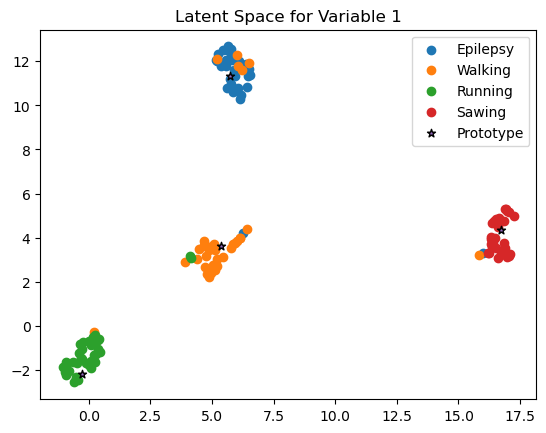

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


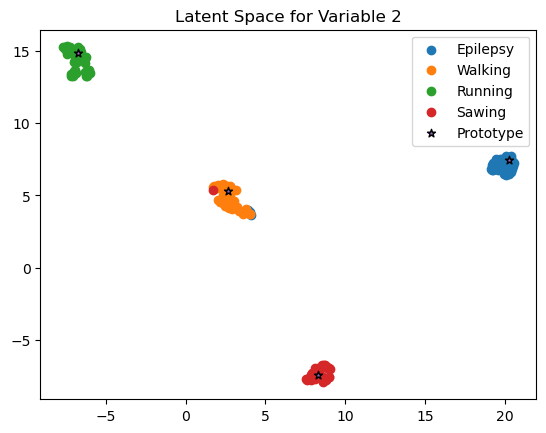

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


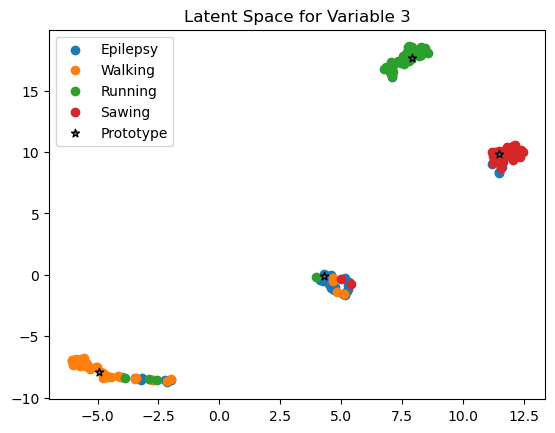

In [61]:
trainer.plot_all_latent_spaces_with_prototypes()

100%|██████████| 100/100 [03:20<00:00,  2.01s/it]


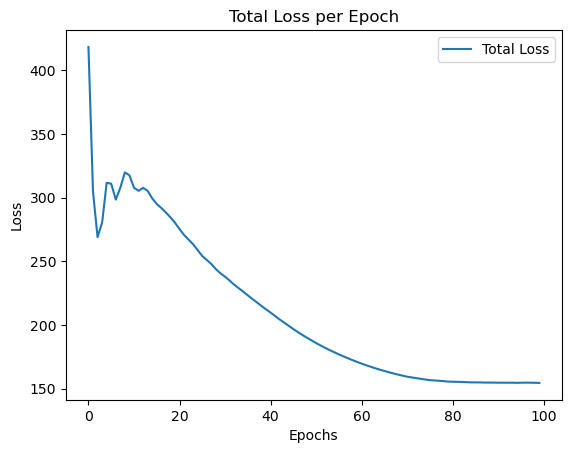

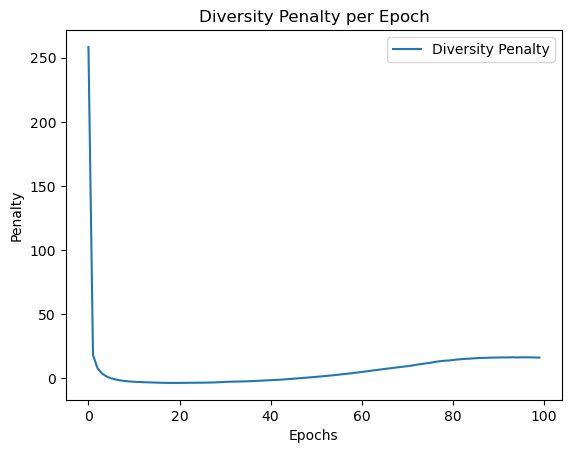

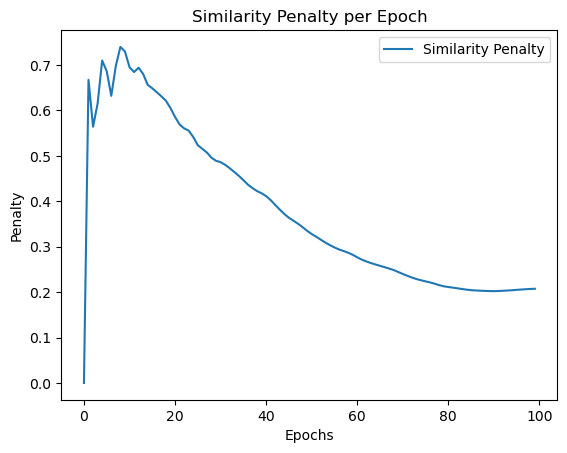

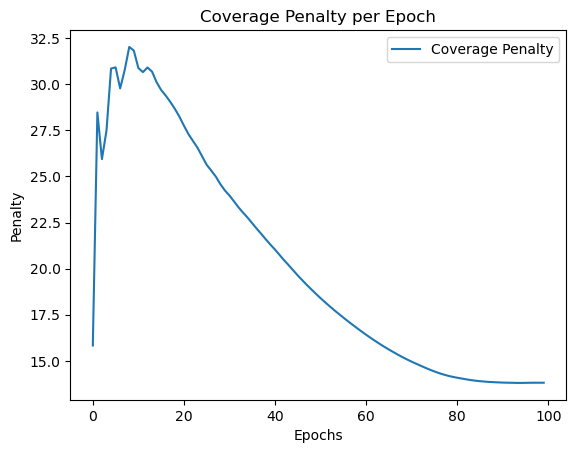

In [62]:
trainer.train()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


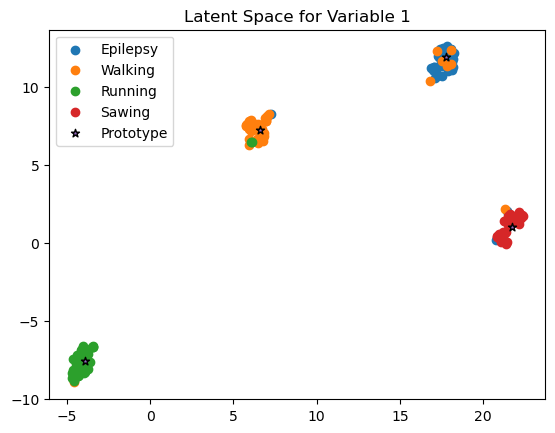

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


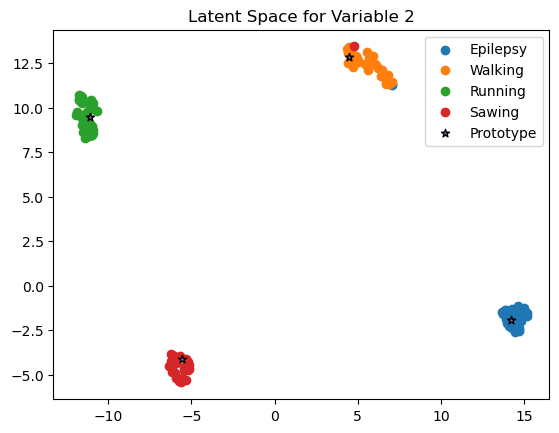

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


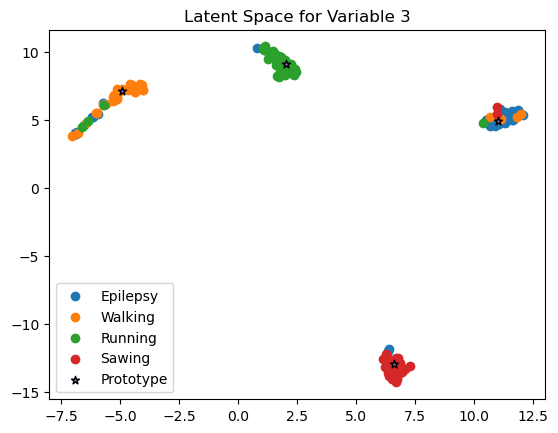

In [63]:
trainer.plot_all_latent_spaces_with_prototypes()

In [64]:
trainer.eval()

Accuracy: 0.9927536231884058


In [65]:
save = True
if save:
    torch.save(trainer.state_dict(), "/Users/bhaveshkalisetti/Desktop/mmbs/models/epilepsy/new/single_variable_prototypes.dat")